## Import Libraries

In [ ]:
!pip install qiskit

!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 66.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
from qiskit import QuantumCircuit,transpile, ClassicalRegister, QuantumRegister
from qiskit.quantum_info import Kraus, SuperOp
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.quantum_info import Statevector,DensityMatrix,state_fidelity,partial_trace, Operator
from matplotlib import pyplot as plt
from functools import reduce
from scipy.linalg import expm
import pandas as pd
from qiskit_aer import AerSimulator
import qiskit.circuit.classical as qiskit_classical
#from qiskit.opflow import I, Z, StateFn, PauliExpectation, CircuitSampler
#from qiskit import Aer, execute, transpile


# Import from Qiskit Aer noise module
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)

ModuleNotFoundError: No module named 'qiskit'

Hamiltonian:

$H=-h(X_1+X_2)-J Z_1 Z_2$

Trotter formula:

$e^{-iH t}=(e^{i h X_1 \Delta t}e^{i h X_2 \Delta t}e^{i J Z_1 Z_2 \Delta t})^{N_{\text{Trot}}},$

where $\Delta t=t/N_{\text{Trot}}$.

## AER Pure SWAPNET

### Set Base Funcs for base state with noise

In [ ]:
def circuit_with_noise_at_end(qc, d, epsilon):
    # Define the depolarizing error
    depolarizing = depolarizing_error(epsilon, d)

    # Apply the depolarizing noise to each d-sized register
    qc.append(depolarizing, range(d, 2*d))  # Second register
    qc.append(depolarizing, range(2*d, 3*d))  # Third register
    qc.append(depolarizing, range(3*d, 4*d))  # Fourth register

    return qc



def getExactState(n_qubits):
    # Create an initial state (|00...0>)
    initial_state = np.zeros(2**n_qubits)
    #print('Initial array:', initial_state)
    initial_state[0] = 1
    pure_state = DensityMatrix(initial_state)

    return pure_state

# Input state without purification, used for benchmarking

def getInputRho(epsilon, d):

    # Create a Quantum Circuit acting on a quantum register of d qubits

    depolarizing = depolarizing_error(epsilon, d)
    qc = QuantumCircuit(d)
    qc.append(depolarizing, [0, d-1])
    state = DensityMatrix(qc)

    return state

### Set SWAPNET

In [ ]:

def get_noisy_sampled(d, epsilon):

    # Select Aer Simulator backend
    simulator = AerSimulator()

    def execute_circuit_on_state(qc):
        """ Executes a circuit on the AerSimulator and returns the state result. """
        qc_transpiled = transpile(qc, simulator)
        result = simulator.run(qc_transpiled).result()
        return result.get_statevector(qc_transpiled)


    # Initialize quantum circuit with classical registers
    qc = QuantumCircuit(4 * d)  # Extra qubit and classical bit for parity check

    # Apply noise (assuming function exists)
    qc = circuit_with_noise_at_end(qc, d, epsilon)

    qc.save_statevector()
    state = execute_circuit_on_state(qc)

    return state
def measure_expectation_value(qc, d, shots=1024):
    """ Computes the expectation value of I ⊗ I ⊗ I ⊗ |0><0| using Aer """
    simulator = AerSimulator()

    # Define the operator I ⊗ I ⊗ I ⊗ |sigma><sigma| = I ⊗ I ⊗ I ⊗ |0><0|
    op = I.tensor(I).tensor(I)  # Identity for q0, q1, q2
    for _ in range(d):  # |0><0| for q3 (represented as (I+Z)/2)
        op = op.tensor((I + Z) / 2)

    # Convert to expectation value form
    measurable_expression = StateFn(op, is_measurement=True) @ StateFn(qc)

    # Convert to expectation value object
    expectation = PauliExpectation().convert(measurable_expression)

    # Sample using AerSimulator
    sampler = CircuitSampler(simulator).convert(expectation)

    # Compute expectation value
    expectation_value = sampler.eval()

    return expectation_value

def get_QPA_circuit(d, epsilon, N):

    # Select Aer Simulator backend
    simulator = AerSimulator()



    cr_q0 = ClassicalRegister(d)
    qr_all = QuantumRegister(4*d)

    # Initialize quantum circuit with classical registers
    qcSWAP = QuantumCircuit(qr_all, cr_q0)  # Extra qubit and classical bit for parity check

    # Apply noise (assuming function exists)
    qcSWAP = circuit_with_noise_at_end(qcSWAP, d, epsilon)

    def recursive(N,qc):
      for k in range(d):
        qc.reset(k)
      qc.h(0)#q0_firstqbit = |0>+|1>/sqrt2
      for k in range(d-1):
        qc.cx(0,1+k)#q0 = |0000...> + |1111...>/sqrt2
      # Apply the first CSWAP gate controlled by q0, targeting q1 and q2
      for k in range(d):
        qc.cswap(0+k, k+d, k+2*d)#|+>_k x SYM12_k + |->_k x AntiSYM12_k /norm

      # Apply the second Hadamard gate to q0
      for k in range(d):
        qc.h(k) #|0> x SYM12 + |1> x AntiSYM12 /norm
      # Measure qubits 0 to d-1 into classical bits 0 to d-1




      for i in range(d): #Measure the control registers and find z
          qc.measure(i, cr_q0[i])
          if i==0:
            parity_control = qiskit_classical.expr.lift(cr_q0[i])
          else:
            parity_control = qiskit_classical.expr.bit_xor(parity_control, cr_q0[i])

      with qc.if_test(parity_control) as _else:
        #--------Z=1
        pass
      with _else:
        #---------Z = 0
        # qc.x(d+1) # Good test to make sure it's working
        for k in range(d):
          qc.swap(k+2*d, k+3*d) #Swap q2 with q3
        if N!=1:
          qc = recursive(N-1,qc) #Do it again unless it was the final iteration of the SWAPNET
      return qc
    if N!=0:
      qc = recursive(N,qcSWAP)
    else:
      qc = qcSWAP
    # Gets Measure register q3 and save in the classical register
    for i in range(d):
        qc.measure(3*d+i, cr_q0[i])
    return qc

def run_qc_and_return_state(qc):

    # Select Aer Simulator backend
    simulator = AerSimulator()

    def execute_circuit_on_state(qc):
        """ Executes a circuit on the AerSimulator and returns the state result. """
        qc_transpiled = transpile(qc, simulator)
        result = simulator.run(qc_transpiled).result()
        return result.get_statevector(qc_transpiled)

    qc.save_statevector()
    state = execute_circuit_on_state(qc)

    return state

def run_qc_and_return_result(qc,shots=1024):

    # Select Aer Simulator backend
    simulator = AerSimulator()

    def execute_circuit_on_state(qc):
        """ Executes a circuit on the AerSimulator and returns the state result. """
        qc_transpiled = transpile(qc, simulator)
        result = simulator.run(qc_transpiled,shots=shots, memory=True).result()
        return result

    result = execute_circuit_on_state(qc)

    return result

# def run_qc_and_measure_all(qc):

# Run the function
d=4
epsilon = 0.3
N_qpa = 2
QPA = get_QPA_circuit(d, epsilon, N_qpa)
results = run_qc_and_return_result(QPA)
memory = results.get_memory()
print(memory)

#psi_purified = run_qc_and_return_state(QPA)
#psi_base = get_noisy_sampled(d, epsilon)
#psi_purified.draw('latex')
#psi_base.draw('latex')
#QPA.draw()


['0000', '0000', '0000', '0000', '0000', '0000', '0000', '0000', '0000', '0000', '0000', '1010', '0000', '0000', '0000', '0000', '0000', '1010', '0011', '0000', '0000', '0000', '0000', '0000', '0000', '0000', '0000', '0000', '0101', '0000', '0000', '0000', '0000', '0000', '0011', '0000', '0000', '0000', '0000', '0000', '0000', '0000', '0000', '0000', '0000', '0101', '0000', '0000', '0001', '0000', '0010', '0000', '0000', '1101', '0000', '0000', '0000', '0000', '0000', '0000', '0000', '0000', '0011', '0000', '0000', '0100', '0000', '0010', '1010', '0000', '0000', '0010', '0000', '0000', '0000', '0000', '0000', '0000', '0000', '0000', '0000', '0000', '1001', '0000', '0000', '0000', '0000', '0000', '1001', '0000', '0000', '0000', '0110', '0000', '0000', '0101', '0000', '0000', '0000', '0000', '0000', '0000', '1011', '0000', '1000', '0000', '0000', '0000', '0000', '1100', '0000', '1111', '0000', '0000', '0000', '0001', '0101', '0000', '0000', '1111', '0000', '0101', '0011', '0000', '0000',

Running: Epsilon=0.0
Running: Epsilon=0.0, Nqpa=0
For Epsilon=0.0, Nqpa=0, found the QPA in 0.00 seconds
For Epsilon=0.0, Nqpa=0, found the Results in 0.12 seconds
For Epsilon=0.0, Nqpa=0, found the Fidelity in 0.01 seconds
Total time for Epsilon=0.0, Nqpa=0: 0.14 seconds

Running: Epsilon=0.0, Nqpa=1
For Epsilon=0.0, Nqpa=1, found the QPA in 0.00 seconds
For Epsilon=0.0, Nqpa=1, found the Results in 3.59 seconds
For Epsilon=0.0, Nqpa=1, found the Fidelity in 0.01 seconds
Total time for Epsilon=0.0, Nqpa=1: 3.60 seconds

Running: Epsilon=0.0, Nqpa=2
For Epsilon=0.0, Nqpa=2, found the QPA in 0.00 seconds
For Epsilon=0.0, Nqpa=2, found the Results in 7.44 seconds
For Epsilon=0.0, Nqpa=2, found the Fidelity in 0.01 seconds
Total time for Epsilon=0.0, Nqpa=2: 7.45 seconds

Running: Epsilon=0.05
Running: Epsilon=0.05, Nqpa=0
For Epsilon=0.05, Nqpa=0, found the QPA in 0.01 seconds
For Epsilon=0.05, Nqpa=0, found the Results in 0.13 seconds
For Epsilon=0.05, Nqpa=0, found the Fidelity in 0.01

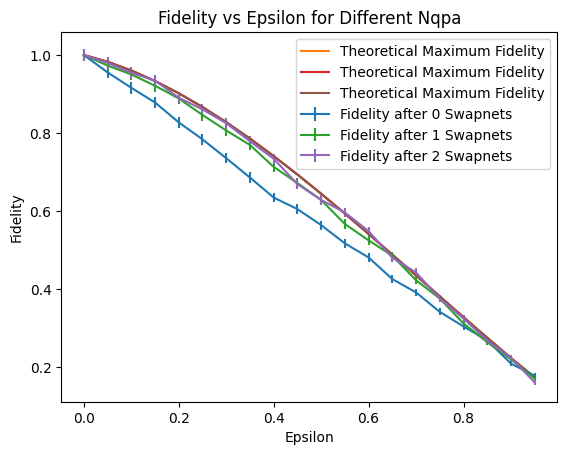

In [ ]:
#DO THE PLOTTING -------------------------
import numpy as np
import matplotlib.pyplot as plt
import time  # Import time module for tracking execution time

list_of_epsilon = [i * 0.05 for i in range(20)]
list_of_Nqpa = [0, 1, 2]
purified_fidelity = {i: [] for i in list_of_Nqpa}
theorical_fidelity=[]
d = 3
shots = 1024*4

for epsilon in list_of_epsilon:
    #The theoretical maximum fidelity attainable for QPA is 1/96 (-8 + 7 epsilon) (-12 + 7 (-1 + epsilon) epsilon)
    theorical_fidelity.append(1/96*(-8 + 7*epsilon)*(-12 + 7*(-1 + epsilon)*epsilon))
    print(f'Running: Epsilon={epsilon}')
    for Nqpa in list_of_Nqpa:
        print(f'Running: Epsilon={epsilon}, Nqpa={Nqpa}')
        start_time = time.time()  # Start timing

        QPA = get_QPA_circuit(d, epsilon, Nqpa)
        mid_time_qpa = time.time()  # Time after generating QPA
        print(f'For Epsilon={epsilon}, Nqpa={Nqpa}, found the QPA in {mid_time_qpa - start_time:.2f} seconds')

        results = run_qc_and_return_result(QPA, shots)
        mid_time_results = time.time()  # Time after running the circuit
        print(f'For Epsilon={epsilon}, Nqpa={Nqpa}, found the Results in {mid_time_results - mid_time_qpa:.2f} seconds')

        memory = results.get_memory()

        # Fidelity: fraction of results where q3 register is all 0s
        fidelity = memory.count('0' * d) / len(memory)
        purified_fidelity[Nqpa].append(fidelity)

        end_time = time.time()  # Time after computing fidelity
        print(f'For Epsilon={epsilon}, Nqpa={Nqpa}, found the Fidelity in {end_time - mid_time_results:.2f} seconds')
        print(f'Total time for Epsilon={epsilon}, Nqpa={Nqpa}: {end_time - start_time:.2f} seconds\n')

# Plot results
for Nqpa in list_of_Nqpa:
    fidelity = np.array(purified_fidelity[Nqpa])
    plt.errorbar(list_of_epsilon, purified_fidelity[Nqpa],
                 yerr=np.sqrt(fidelity/shots), label=f'Fidelity after {Nqpa} Swapnets')

    plt.plot(list_of_epsilon, theorical_fidelity, label='Theoretical Maximum Fidelity')

plt.xlabel('Epsilon')
plt.ylabel('Fidelity')
plt.title('Fidelity vs Epsilon for Different Nqpa')
plt.legend()
plt.show()
